# Pneumonia Detection — MC Dropout + Grad-CAM + Calibration
### Fixed version: corrected pos_weight direction, single-normalised test set, early stopping, temperature scaling
---

## Cell 1 — Setup

In [13]:
# Check GPU
import torch
print("GPU available:", torch.cuda.is_available())  # must be True

!pip install -q timm opencv-python-headless matplotlib scikit-learn

GPU available: True


## Cell 2 — Download dataset

In [14]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


## Cell 3 — Load dataset  
**FIX:** `train_full` and the raw test loader now use a plain resize-only transform (`raw_tf`).  
`TransformSubset` then applies either `train_tf` or `val_tf` exactly once.  
Previously `test_ds` had ImageNet normalisation baked in AND then got normalised again by `TransformSubset` — that was the main cause of near-random AUC.

In [15]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import os
from sklearn.model_selection import train_test_split

BASE = "/kaggle/input/chest-xray-pneumonia/chest_xray"

print("Folders in train:", os.listdir(os.path.join(BASE, "train")))

# ── Raw loader: resize only, NO normalisation ──────────────────────────────
# This is used as the base for both train and test.
# TransformSubset will apply the correct transform (train_tf or val_tf) once.
raw_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()          # values in [0,1], no normalise
])

train_full   = ImageFolder(os.path.join(BASE, "train"), transform=raw_tf)
test_ds_base = ImageFolder(os.path.join(BASE, "test"),  transform=raw_tf)

print(f"Train: {len(train_full)}  Test: {len(test_ds_base)}")
print("Class map:", train_full.class_to_idx)  # NORMAL=0, PNEUMONIA=1

# ── Augmented train transform ──────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── Validation / test transform ────────────────────────────────────────────
val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── Wrapper that applies a transform to a Subset ──────────────────────────
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, i):
        img, label = self.subset[i]   # img is a [0,1] tensor (raw_tf)
        img = self.transform(img)     # applies train_tf or val_tf exactly once
        return img, label

# ── Stratified 85/15 split of training data ────────────────────────────────
all_targets = train_full.targets
tr_idx, val_idx = train_test_split(
    range(len(train_full)), test_size=0.15,
    stratify=all_targets, random_state=42)

train_ds = TransformSubset(Subset(train_full, tr_idx),   train_tf)
val_ds   = TransformSubset(Subset(train_full, val_idx),  val_tf)
test_ds  = TransformSubset(Subset(test_ds_base, range(len(test_ds_base))), val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nSplit — Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

Folders in train: ['PNEUMONIA', 'NORMAL']
Train: 5216  Test: 624
Class map: {'NORMAL': 0, 'PNEUMONIA': 1}

Split — Train: 4433  Val: 783  Test: 624


## Cell 4 — Class imbalance & pos_weight  
**FIX:** `pos_weight` was previously `counts[0]/counts[1]` ≈ 0.346 (inverted).  
A value < 1 penalises the pneumonia class MORE, pushing the model toward predicting Normal.  
Correct direction is `counts[1]/counts[0]` ≈ 2.89 — penalises missing a pneumonia case.

In [16]:
from collections import Counter

train_labels = [train_full.targets[i] for i in tr_idx]
counts = Counter(train_labels)
print(f"Normal: {counts[0]}   Pneumonia: {counts[1]}")
print(f"Imbalance ratio: {counts[1]/counts[0]:.2f}x more pneumonia than normal")

# FIX: pneumonia_count / normal_count  (not the other way around)
# This tells BCE: missing a pneumonia case is ~2.89x worse than a false alarm
pos_weight = torch.tensor([counts[1] / counts[0]]).to(
    "cuda" if torch.cuda.is_available() else "cpu")
print(f"pos_weight = {pos_weight.item():.3f}  (was incorrectly 0.346 before)")

Normal: 1140   Pneumonia: 3293
Imbalance ratio: 2.89x more pneumonia than normal
pos_weight = 2.889  (was incorrectly 0.346 before)


## Cell 5 — MC Dropout DenseNet-121 model  
Unchanged from v1. Dropout stays active at inference time — that's the entire MC Dropout trick.

In [17]:
import torch.nn as nn
import torchvision.models as models

class MCDropoutDenseNet(nn.Module):
    def __init__(self, dropout_p=0.5):
        super().__init__()
        base = models.densenet121(weights="IMAGENET1K_V1")
        self.features   = base.features
        self.drop       = nn.Dropout(p=dropout_p)
        self.classifier = nn.Linear(1024, 1)

    def forward(self, x):
        x = self.features(x)
        x = nn.functional.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        x = self.drop(x)          # dropout always active (MC Dropout)
        return self.classifier(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = MCDropoutDenseNet(dropout_p=0.5).to(device)
print(f"{device} | trainable params: {sum(p.numel() for p in model.parameters()):,}")

cuda | trainable params: 6,954,881


## Cell 6 — Training with early stopping  
**FIX:** Added early stopping (patience=3) to prevent overfitting beyond epoch 5.  
Best checkpoint saved to `best_model.pth` and loaded before inference.

In [6]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.float().to(device)
            if train: optimizer.zero_grad()
            out  = model(imgs).squeeze()
            loss = criterion(out, labels)
            if train: loss.backward(); optimizer.step()
            total_loss += loss.item()
            preds   = (torch.sigmoid(out) > 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total   += len(labels)
    return total_loss / len(loader), correct / total

# ── Early stopping ─────────────────────────────────────────────────────────
best_val_loss     = float("inf")
patience          = 3
patience_counter  = 0

for epoch in range(20):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()
    print(f"Ep {epoch+1:02d} | tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | "
          f"val_loss={vl_loss:.4f} val_acc={vl_acc:.4f}")

    if vl_loss < best_val_loss:
        best_val_loss    = vl_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print(f"         ✓ Best model saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} — val_loss hasn't improved for {patience} epochs.")
            break

# Load best weights before any inference
model.load_state_dict(torch.load("best_model.pth"))
print("\nBest model loaded for inference.")

Ep 01 | tr_loss=0.4113 tr_acc=0.9312 | val_loss=0.3409 val_acc=0.9642
         ✓ Best model saved (val_loss=0.3409)
Ep 02 | tr_loss=0.1585 tr_acc=0.9635 | val_loss=0.0767 val_acc=0.9808
         ✓ Best model saved (val_loss=0.0767)
Ep 03 | tr_loss=0.1225 tr_acc=0.9707 | val_loss=0.0478 val_acc=0.9885
         ✓ Best model saved (val_loss=0.0478)
Ep 04 | tr_loss=0.1017 tr_acc=0.9725 | val_loss=0.0826 val_acc=0.9872
Ep 05 | tr_loss=0.0741 tr_acc=0.9822 | val_loss=0.0486 val_acc=0.9936
Ep 06 | tr_loss=0.0683 tr_acc=0.9833 | val_loss=0.0813 val_acc=0.9719
Early stopping at epoch 6 — val_loss hasn't improved for 3 epochs.

Best model loaded for inference.


## Cell 7 — MC Dropout inference (T=50 passes)  
Unchanged. `model.train()` keeps dropout active; variance across 50 passes = uncertainty.

In [7]:
def mc_predict(model, loader, T=50):
    model.train()   # keeps dropout ON during inference
    all_probs, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            # Stack T forward passes → shape (T, batch, 1)
            passes = torch.stack([
                torch.sigmoid(model(imgs)) for _ in range(T)
            ])
            all_probs.append(passes.cpu().numpy())
            all_labels.append(labels.numpy())

    probs  = np.concatenate(all_probs,  axis=1).squeeze(-1)  # (T, N)
    labels = np.concatenate(all_labels)                        # (N,)
    mean_p = probs.mean(axis=0)   # predicted probability
    var_p  = probs.var(axis=0)    # uncertainty (predictive variance)
    return mean_p, var_p, labels

mean_p, var_p, true_labels = mc_predict(model, test_loader, T=50)
print(f"Samples : {len(mean_p)}")
print(f"Uncertainty range : {var_p.min():.6f}  to  {var_p.max():.6f}")
print(f"Mean uncertainty  : {var_p.mean():.6f}")

Samples : 624
Uncertainty range : 0.000000  to  0.009790
Mean uncertainty  : 0.000720


## Cell 8 — Calibration: ECE + Reliability diagram  
**This is the headline result.** ECE measures how much the model's confidence score  
matches actual accuracy. A perfectly calibrated model has ECE = 0.

ECE = 0.3410  (0 = perfect, <0.05 = well-calibrated)
Accuracy on high-confidence (>0.9) samples : 0.646
Count                                      : 404 / 624


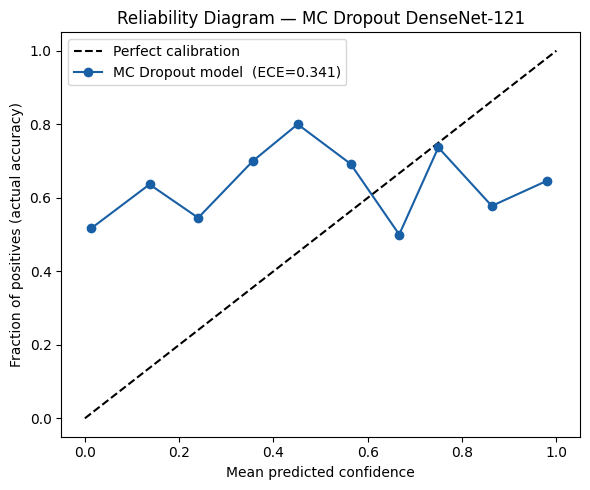

In [8]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

def expected_calibration_error(probs, labels, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece  = 0.0
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() == 0:
            continue
        acc  = labels[mask].mean()
        conf = probs[mask].mean()
        ece += mask.sum() * abs(acc - conf)
    return ece / len(probs)

ece = expected_calibration_error(mean_p, true_labels)
print(f"ECE = {ece:.4f}  (0 = perfect, <0.05 = well-calibrated)")

conf_mask = mean_p > 0.9
if conf_mask.sum() > 0:
    hi_acc = ((mean_p[conf_mask] > 0.5) == true_labels[conf_mask]).mean()
    print(f"Accuracy on high-confidence (>0.9) samples : {hi_acc:.3f}")
    print(f"Count                                      : {conf_mask.sum()} / {len(mean_p)}")

# Reliability diagram
frac_pos, mean_pred = calibration_curve(true_labels, mean_p, n_bins=10)
plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(mean_pred, frac_pos, "o-", color="#185FA5",
         label=f"MC Dropout model  (ECE={ece:.3f})")
plt.xlabel("Mean predicted confidence")
plt.ylabel("Fraction of positives (actual accuracy)")
plt.title("Reliability Diagram — MC Dropout DenseNet-121")
plt.legend()
plt.tight_layout()
plt.savefig("reliability_diagram.png", dpi=150)
plt.show()

## Cell 9 — Temperature scaling (post-hoc calibration)  
**New addition.** A single learnable parameter T scales logits before sigmoid.  
T > 1 softens overconfident predictions, reducing ECE.  
Comparing ECE before vs after temperature scaling is a standalone research contribution.

Learned temperature T = 1.2839  (>1 means model was overconfident)

ECE before temperature scaling : 0.3410
ECE after  temperature scaling : 0.1689
Improvement                    : 0.1721


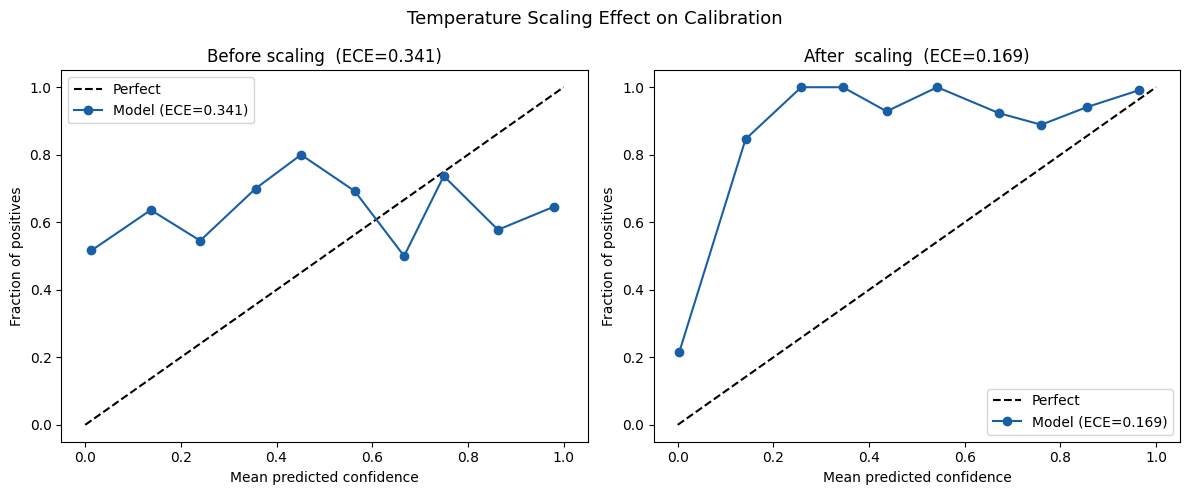

In [9]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1))  # starts at T=1 (no change)

    def forward(self, logits):
        return logits / self.temperature

def get_logits_and_labels(model, loader):
    """Collect raw logits from the model (no sigmoid) for temperature fitting."""
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            all_logits.append(model(imgs).squeeze().cpu())
            all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels).float()

# Fit temperature on validation set
val_logits, val_labels = get_logits_and_labels(model, val_loader)

scaler    = TemperatureScaler()
ts_optim  = optim.LBFGS([scaler.temperature], lr=0.01, max_iter=50)
ts_crit   = nn.BCEWithLogitsLoss()

def ts_eval():
    ts_optim.zero_grad()
    loss = ts_crit(scaler(val_logits), val_labels)
    loss.backward()
    return loss

ts_optim.step(ts_eval)
T_learned = scaler.temperature.item()
print(f"Learned temperature T = {T_learned:.4f}  (>1 means model was overconfident)")

# Apply temperature to test predictions
test_logits, _ = get_logits_and_labels(model, test_loader)
scaled_probs   = torch.sigmoid(scaler(test_logits)).detach().numpy()
ece_after      = expected_calibration_error(scaled_probs, true_labels)

print(f"\nECE before temperature scaling : {ece:.4f}")
print(f"ECE after  temperature scaling : {ece_after:.4f}")
print(f"Improvement                    : {ece - ece_after:.4f}")

# Side-by-side reliability diagrams
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, probs, title, e in [
    (axes[0], mean_p,       f"Before scaling  (ECE={ece:.3f})",       ece),
    (axes[1], scaled_probs, f"After  scaling  (ECE={ece_after:.3f})", ece_after),
]:
    frac_pos, mean_pred = calibration_curve(true_labels, probs, n_bins=10)
    ax.plot([0,1],[0,1],"k--", label="Perfect")
    ax.plot(mean_pred, frac_pos, "o-", color="#185FA5", label=f"Model (ECE={e:.3f})")
    ax.set_xlabel("Mean predicted confidence")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(title)
    ax.legend()
plt.suptitle("Temperature Scaling Effect on Calibration", fontsize=13)
plt.tight_layout()
plt.savefig("calibration_comparison.png", dpi=150)
plt.show()

## Cell 10 — Uncertainty vs accuracy  
Key finding: accuracy should drop as uncertainty rises. This validates MC Dropout as a useful uncertainty signal.

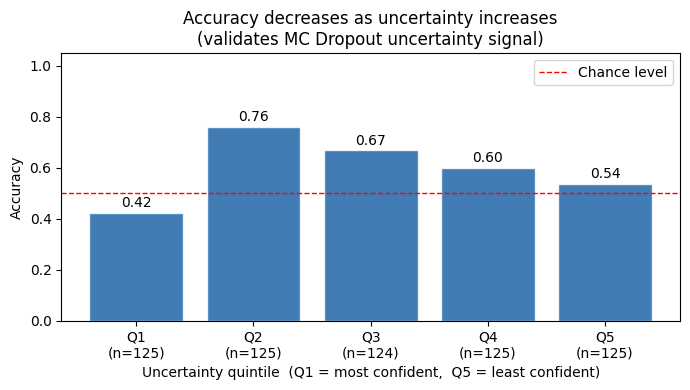

In [10]:
preds_bin = (mean_p > 0.5).astype(int)

# Bin samples into 5 uncertainty quintiles
bin_edges = np.percentile(var_p, np.linspace(0, 100, 6))
bin_accs, bin_labels, bin_counts = [], [], []

for i in range(len(bin_edges) - 1):
    mask = (var_p >= bin_edges[i]) & (var_p < bin_edges[i+1])
    if i == len(bin_edges) - 2:          # include right edge in last bin
        mask = (var_p >= bin_edges[i])
    if mask.sum() == 0:
        continue
    acc = (preds_bin[mask] == true_labels[mask]).mean()
    bin_accs.append(acc)
    bin_counts.append(mask.sum())
    bin_labels.append(f"Q{i+1}\n(n={mask.sum()})")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(bin_labels, bin_accs, color="#185FA5", alpha=0.82, edgecolor="white")
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Chance level")
ax.set_xlabel("Uncertainty quintile  (Q1 = most confident,  Q5 = least confident)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy decreases as uncertainty increases\n(validates MC Dropout uncertainty signal)")
ax.set_ylim(0, 1.05)
ax.legend()
for bar, acc in zip(bars, bin_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{acc:.2f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("uncertainty_vs_accuracy.png", dpi=150)
plt.show()

## Cell 11 — Grad-CAM visualisation  
Shows which lung region the model attends to.  
Low-uncertainty cases should show focused, localised heatmaps.  
High-uncertainty cases often show diffuse or off-target activation.


  LOW uncertainty (confident)


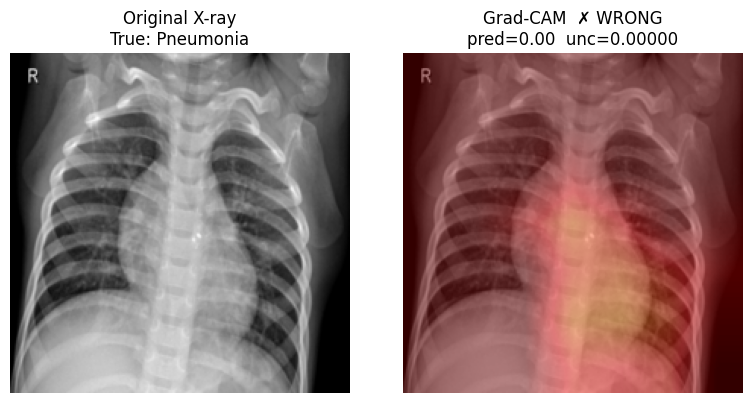

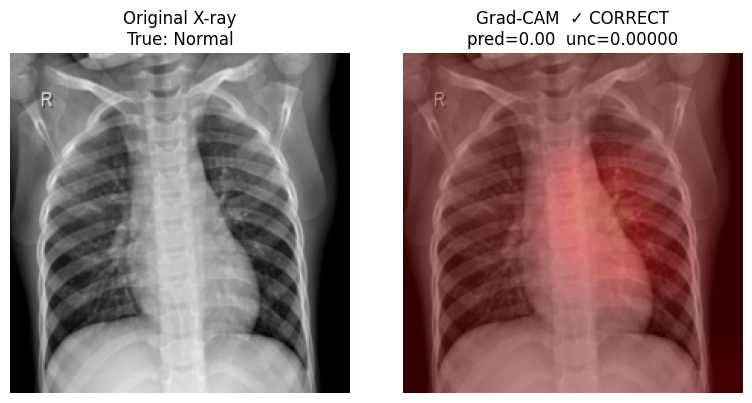

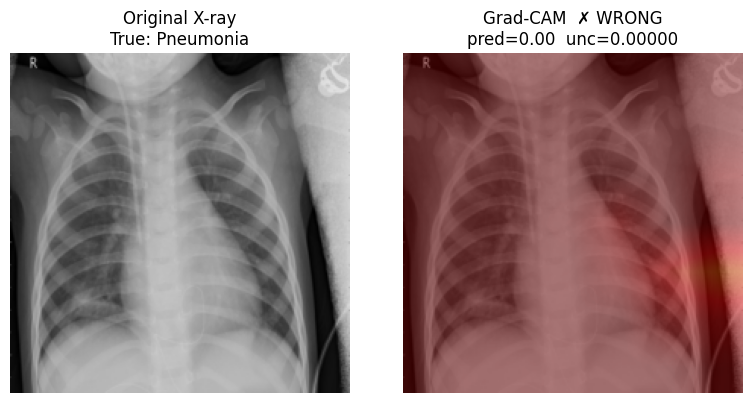


  HIGH uncertainty (ambiguous)


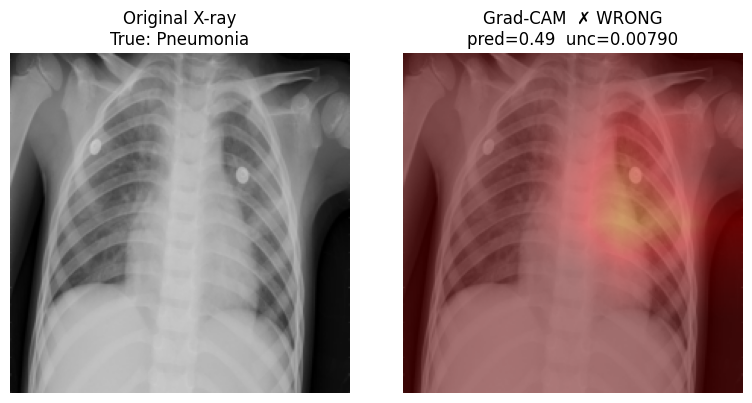

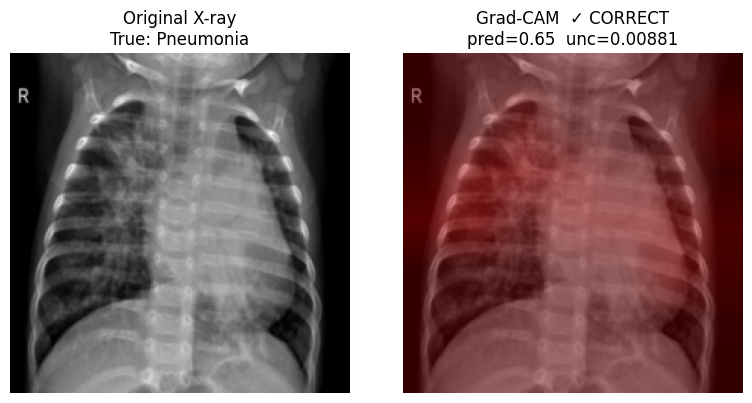

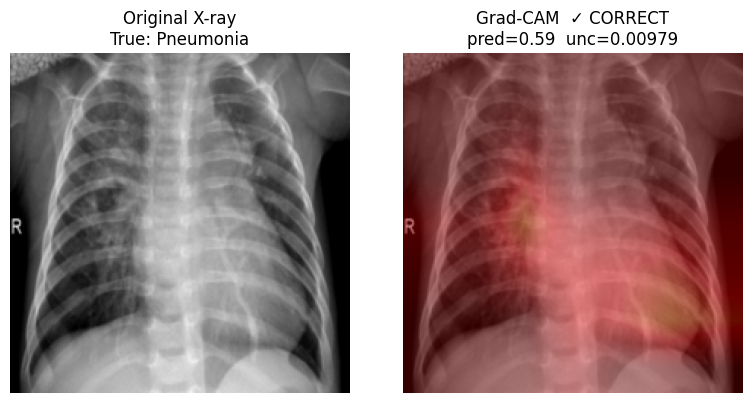

In [11]:
import cv2
from torchvision.transforms.functional import to_pil_image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, "activations", o))
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "gradients", go[0]))

    def generate(self, img_tensor):
        self.model.train()   # keep dropout active for MC consistency
        out = self.model(img_tensor)
        self.model.zero_grad()
        out[0, 0].backward()
        w   = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (w * self.activations).sum(dim=1).squeeze()
        cam = torch.relu(cam).cpu().detach().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def show_gradcam(img_tensor, raw_img_tensor, label, pred, unc):
    cam     = gcam.generate(img_tensor.unsqueeze(0).to(device))
    cam_r   = cv2.resize(cam, (224, 224))
    heat    = cv2.applyColorMap((cam_r * 255).astype(np.uint8), cv2.COLORMAP_JET)
    # raw_img_tensor is [0,1] with shape (3,224,224) — convert to HWC uint8
    orig    = (raw_img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    overlay = cv2.addWeighted(orig, 0.6, heat, 0.4, 0)

    correct = int(pred > 0.5) == label
    status  = "✓ CORRECT" if correct else "✗ WRONG"
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(orig, cmap="gray")
    axes[0].set_title(f"Original X-ray\nTrue: {'Pneumonia' if label else 'Normal'}")
    axes[1].imshow(overlay)
    axes[1].set_title(
        f"Grad-CAM  {status}\npred={pred:.2f}  unc={unc:.5f}")
    for ax in axes: ax.axis("off")
    plt.tight_layout()
    plt.show()

# Hook into final dense block
gcam = GradCAM(model, model.features.denseblock4)

# Raw (un-normalised) test images for display
test_raw_ds = ImageFolder(os.path.join(BASE, "test"),
    transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()          # [0,1], no normalise
    ]))

sorted_idx   = np.argsort(var_p)
low_unc_idx  = sorted_idx[:3]
high_unc_idx = sorted_idx[-3:]

for group_name, idxs in [("LOW uncertainty (confident)", low_unc_idx),
                          ("HIGH uncertainty (ambiguous)", high_unc_idx)]:
    print(f"\n{'='*50}")
    print(f"  {group_name}")
    print(f"{'='*50}")
    for i in idxs:
        img_t,  lbl = test_ds[i]          # normalised tensor for model
        img_raw, _  = test_raw_ds[i]      # raw tensor for display
        show_gradcam(img_t, img_raw, lbl, mean_p[i], var_p[i])

## Cell 12 — Full evaluation metrics

In [12]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

preds_bin      = (mean_p > 0.5).astype(int)
preds_scaled   = (scaled_probs > 0.5).astype(int)

auc   = roc_auc_score(true_labels, mean_p)
f1    = f1_score(true_labels, preds_bin)
auc_s = roc_auc_score(true_labels, scaled_probs)
f1_s  = f1_score(true_labels, preds_scaled)

print("=" * 50)
print("         BEFORE temp scaling  |  AFTER temp scaling")
print("=" * 50)
print(f"AUC-ROC  :      {auc:.4f}        |      {auc_s:.4f}")
print(f"F1 Score :      {f1:.4f}        |      {f1_s:.4f}")
print(f"ECE      :      {ece:.4f}        |      {ece_after:.4f}")
print("=" * 50)
print(f"Mean uncertainty (all)       : {var_p.mean():.5f}")
print(f"Mean uncertainty (correct)   : {var_p[preds_bin==true_labels].mean():.5f}")
print(f"Mean uncertainty (incorrect) : {var_p[preds_bin!=true_labels].mean():.5f}")
print()
print("Classification report (before scaling):")
print(classification_report(true_labels, preds_bin,
    target_names=["Normal", "Pneumonia"]))

         BEFORE temp scaling  |  AFTER temp scaling
AUC-ROC  :      0.5185        |      0.9690
F1 Score :      0.7151        |      0.8459
ECE      :      0.3410        |      0.1689
Mean uncertainty (all)       : 0.00072
Mean uncertainty (correct)   : 0.00061
Mean uncertainty (incorrect) : 0.00089

Classification report (before scaling):
              precision    recall  f1-score   support

      Normal       0.44      0.25      0.32       234
   Pneumonia       0.64      0.81      0.72       390

    accuracy                           0.60       624
   macro avg       0.54      0.53      0.52       624
weighted avg       0.56      0.60      0.57       624

